<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula11b%20-%20trainable%20weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your (x^1)
   [0.55, 0.87, 0.66], # journey (x^2)
   [0.57, 0.85, 0.64], # starts (x^3)
   [0.22, 0.58, 0.33], # with (x^4)
   [0.77, 0.25, 0.10], # one (x^5)
   [0.05, 0.80, 0.55]] # step (x^6)
)

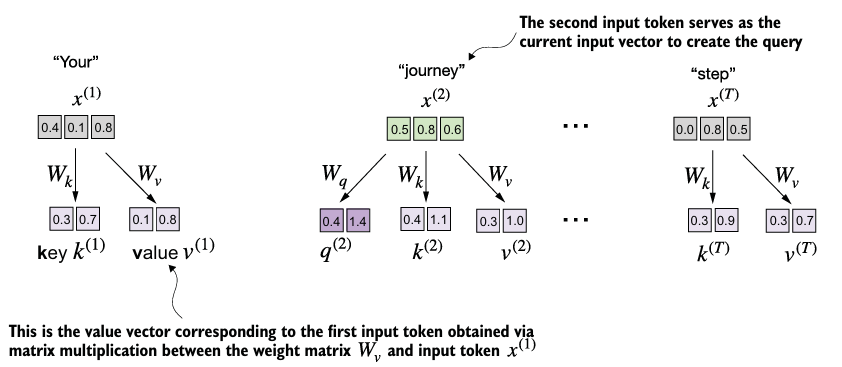

In [21]:
x_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2

In [22]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [23]:
query_2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value
print(query_2)

tensor([0.4306, 1.4551])


In [26]:
keys = inputs @ W_key
values = inputs @ W_value
print(f"keys.shape: {keys.shape}")
print(f"values.shape: {values.shape}")

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


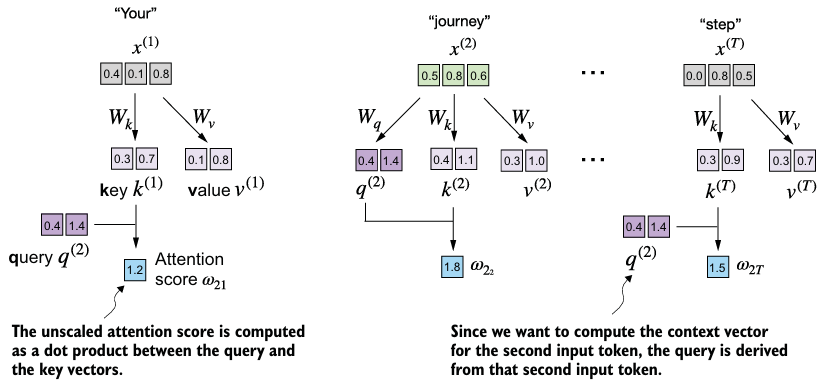

In [28]:
keys_2 = keys[1]
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.8524)


In [29]:
attn_scores_2 = query_2 @ keys.T
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [31]:
d_k = keys.shape[-1]
# scaled-dot product attention
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


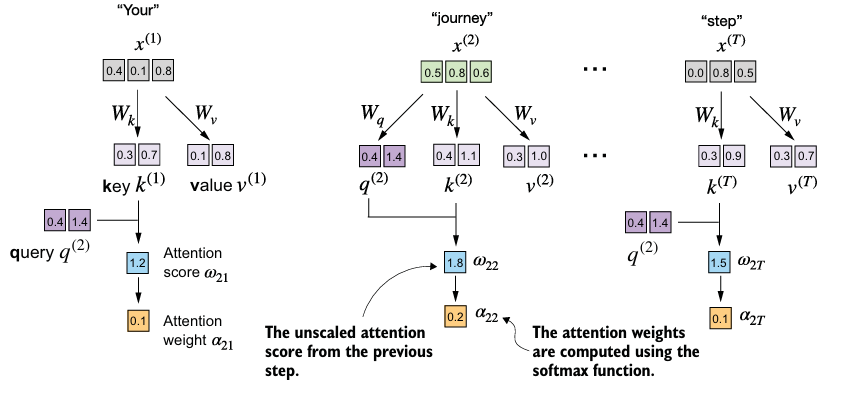

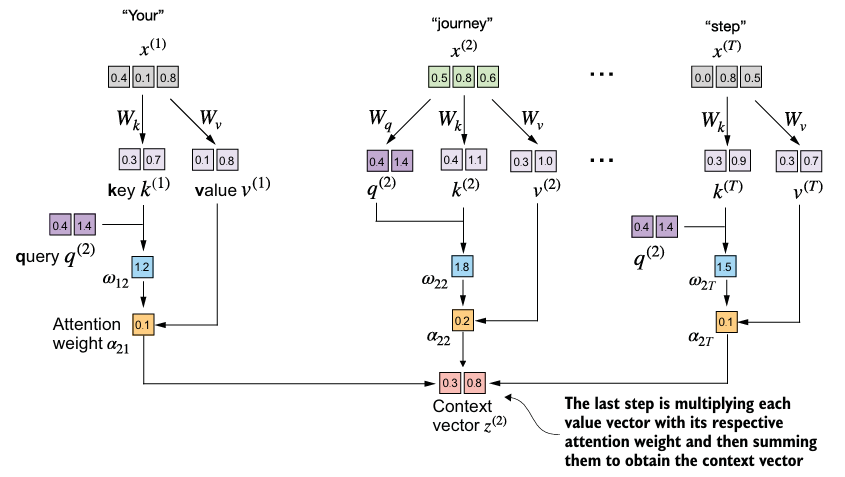

In [32]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


### implementando self-attention em uma class Python

In [35]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
      super().__init__()
      self.W_query = nn.Parameter(torch.rand(d_in, d_out))
      self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
      self.W_value = nn.Parameter(torch.rand(d_in, d_out))
    def forward(self, x):
      queries = x @ self.W_query
      keys    = x @ self.W_key
      values  = x @ self.W_value
      attn_scores = queries @ keys.T
      attn_weights = torch.softmax(
          attn_scores / keys.shape[-1]**0.5 , dim=-1
      )
      context_vec = attn_weights @ values
      return context_vec

In [36]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [37]:
print(context_vec_2)

tensor([0.3061, 0.8210])


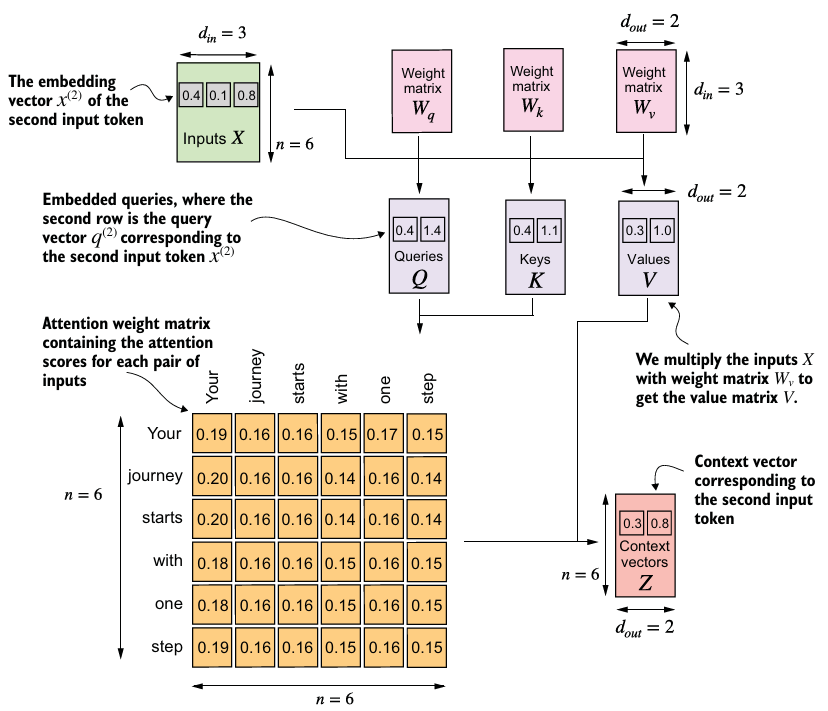

In [38]:
class SelfAttention_v2(nn.Module):
  def __init__(self, d_in, d_out, qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
  def forward(self, X):
    keys = self.W_key(X)
    queries = self.W_query(X)
    values = self.W_value(X)
    attn_scores = queries @ keys.T
    attn_weights = torch.softmax(
        attn_scores / (keys.shape[-1] ** 0.5), dim=-1
    )
    context_vec = attn_weights @ values
    return context_vec

In [39]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)
